# Desempleo vs Morosidad 90+(%) Consumo - Parte 3.

Autor: Arturo Díaz  
Fecha: Septiembre 2026  
**Objetivo**: Crear y aplicar un pipeline de control y validación del modelo ECM de la Parte 2

## I - Introducción

En la Parte 2 de esta serie de publicaciones planteé un ECM para poder predecir la mora consumo 90+ en función del desempleo, y ya contamos con 3 observaciones después del pronóstico que se realizó. Si bien con esta cantidad limitada de observaciones no es posible implementar un backtest concluyente, existen distintos controles que se pueden aplicar mes a mes para el control y validación de este modelo.

La validación de modelos no solo incluye los indicadores clásicos como MAE y RMSE, que comparan tu predicción con el valor real. También es importante revisar la estabilidad de la relación entre las variables, pues un cambio en esta es un cambio en los supuestos con que se construyó el modelo. Para el caso específico de este modelo, al ser una serie de tiempo no aplican métodos como PSI, por lo que lo más adecuado para este modelo en particular es un CUSUM sobre el ECT más la búsqueda de quiebres estructurales en este. En el proceso de búsqueda de quiebres se debe tener en cuenta que en el desarrollo del ECM se decidió excluir la ventana pandémica, pues esta exhibía un comportamiento anómalo; el método propuesto en la presente validación analiza la serie completa, por lo que un potencial quiebre detectado en dicho período no debe ser considerado una señal de alarma.

En este cuaderno muestro una serie de controles que ayudan a validar mensualmente nuestro modelo, y que son facilmente adaptables a otros modelos.

Un punto importante a destacar es que estoy realizando una validación a un modelo que yo mismo desarrollé; por lo general **el equipo validador es distinto al equipo que desarrolló el modelo**. Esto constituye la mayor debilidad de este trabajo, por lo que para mitigar parcialmente esta limitación aplicaré estándares que un validador externo aplicaría: bandas de tolerancia definidas antes de ver los resultados, comparación contra un benchmark, y documentación de los propios errores detectados, teniendo en cuenta que esto no reemplaza la independencia que un validador externo entregaría.

## II - Metodología

Este cuaderno incluye una batería de controles, que incluyen pruebas estadísticas como CUSUM, MAE y RMSE, además de enfoques gráficos y descriptivos. Es importante entender que la validación de modelos (así como todo el ciclo de vida de estos) **debe ser presentada de forma que el público general pueda entenderla**. Para lo anterior he propuesto la siguiente metodología:

1. Análisis descriptivo de las series que componen este modelo (desempleo y morosidad)
2. Comparación gráfica entre pronóstico y valor real.
3. Backtest, comparación contra benchmark y semáforo.
4. CUSUM
5. Búsqueda de quiebres en el ECT
6. Pronóstico de referencia.
7. Log de resultados

## 0.1 - Carga de librerías

In [1]:
# ==============================================================================
# 1. Librerías Nativas del Sistema
# ==============================================================================
import itertools
import json
import warnings
from time import sleep

# ==============================================================================
# 2. Manipulación de Datos y Visualización
# ==============================================================================
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests

# ==============================================================================
# 3. Modelamiento Estadístico y Econometría (Statsmodels)
# ==============================================================================
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Pruebas de Estacionariedad y Cointegración
from statsmodels.tsa.stattools import acf, adfuller, coint, kpss

# Herramientas VECM (para tus análisis de sistemas/vectores)
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank, select_order

# Busqueda de quiebres
import ruptures as rpt

# ==============================================================================
# 4. Configuraciones Globales
# ==============================================================================
warnings.filterwarnings("ignore")


/Users/arturodiaz/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 0.2 - Descarga de datos y Tabla 1 (histórico)

*Esta celda originalmente descargaba datos desde APIs públicas que no requieren autenticación, pero en ocasiones puede arrojar un error de timeout, por lo que opté por descargar la data y dejarla en un CSV. Mantuve este código como markdown en caso de que el lector requiera validar la fuente de datos.*

# ===== Descarga: desempleo (mindicador.cl) =====
all_rows = []
for year in range(2014, 2027):
    url = f"https://mindicador.cl/api/tasa_desempleo/{year}"
    r = requests.get(url, timeout=180)
    if r.status_code == 200:
        data = r.json()
        if "serie" in data:
            for row in data["serie"]:
                all_rows.append({"fecha": row["fecha"], "desempleo": row["valor"]})
    sleep(0.2)

df = pd.DataFrame(all_rows)
df["fecha"] = pd.to_datetime(df["fecha"])
df["desempleo"] = pd.to_numeric(df["desempleo"], errors="coerce")
df = df.sort_values("fecha").drop_duplicates()
df["fecha_cruce"] = df["fecha"].dt.year * 10000 + df["fecha"].dt.month * 100 + 1

# ===== Descarga: mora 90+ consumo (CMF) =====
url = "https://best-sbif-api.azurewebsites.net/Cuadrosv2?FechaFin=20261201&FechaInicio=20090101&Tag=CMF_CONT_MOR_90DMAS_CONSOL_STO_RAZ_PORC_MONT&from=reload"
r = requests.get(url)
r.raise_for_status()
data = r.json()

datos_mora = []
for j in data["series"]:
    for obs in j["observaciones"]:
        datos_mora.append({"codigo": j["codigo"], "fecha": obs["fecha"], "valor": obs["valor"]})
mora_banca = pd.DataFrame(datos_mora)

CODIGO_CONSUMO = "CMF_CONT_MOR_90DMAS_CONSOL_CCS_STO_RAZ_PORC_MONT"
mora_pivot = (
    mora_banca[mora_banca["codigo"] == CODIGO_CONSUMO]
    .pivot_table(index="fecha", values="valor", aggfunc="first")
    .rename(columns={"valor": "Consumo"})
    .reset_index()
)
mora_pivot = mora_pivot.merge(df[["fecha_cruce", "desempleo"]],
                               left_on="fecha", right_on="fecha_cruce", how="left")
mora_pivot["fecha2"] = pd.to_datetime(mora_pivot["fecha"].astype(str), format="%Y%m%d")

# ===== Desestacionalización (mismo método que notebook 2) =====
res_consumo   = seasonal_decompose(mora_pivot["Consumo"],   model="additive", period=12)
res_desempleo = seasonal_decompose(mora_pivot["desempleo"], model="additive", period=12)
mora_pivot["Consumo_sa"]   = res_consumo.observed.values   - res_consumo.seasonal.values
mora_pivot["desempleo_sa"] = res_desempleo.observed.values - res_desempleo.seasonal.values

# ===== TABLA 1: histórico mensual (desempleo + mora, cruda y SA) =====
idx = pd.to_datetime(mora_pivot["fecha2"]).dt.to_period("M").dt.to_timestamp()
Sx = mora_pivot.set_index(idx)[["Consumo", "desempleo", "Consumo_sa", "desempleo_sa"]].sort_index()
Sx.index.name = "fecha"

print(Sx.tail(10).round(3).to_string())

Sx.to_csv("mora_desempleo_202607.csv")

In [2]:
Sx = pd.read_csv("mora_desempleo_202607.csv", index_col=0, parse_dates=True)
Sx

,Consumo,desempleo,Consumo_sa,desempleo_sa
fecha,,,,
2014-03-01,2.088224,6.50,2.073954,6.546681
2014-04-01,2.089532,6.10,2.064758,6.121757
2014-05-01,2.078027,6.30,2.028396,6.016492
2014-06-01,2.080219,6.50,2.040617,6.167590
2014-07-01,2.087967,6.50,2.066510,6.080507
...,...,...,...,...
2026-03-01,2.446283,8.93,2.432013,8.976681
2026-04-01,2.442725,9.11,2.417951,9.131757
2026-05-01,2.537497,9.44,2.487867,9.156492


## 0.3 - Parámetros congelados del modelo (Parte 2)

No se reestima nada acá — estos son los coeficientes ya fijos del ECM final, consolidados en la
celda "PARÁMETROS DEL MODELO FINAL" de la Parte 2. Se definen una sola vez, temprano, porque los
usan varias secciones más abajo (gráficos, CUSUM, pronóstico de referencia).

In [3]:
# --- largo plazo (Gregory-Hansen) ---
c0, lam, beta = -0.3083, -0.3374, 0.3702
BREAK, LAG    = pd.Timestamp("2024-04-01"), 8

# --- corto plazo (ECM) ---
const, gamma  = 0.0011, -0.1731
th1, th2      = 0.1579, 0.1336


## 0.4 - Tabla 2: histórico + pronóstico congelado

In [4]:
forecast = pd.read_csv("pronostico_202604.csv", index_col=0, parse_dates=True)
forecast.index.name = "fecha"

# ===== TABLA 2: histórico + pronóstico =====
control = Sx.merge(forecast, left_index=True, right_index=True, how="outer").sort_index()
control["error_cruda"] = control["Consumo"] - control["central"]
control["error_sa"]    = control["Consumo_sa"] - control["central_sa"]

print(control.tail(15).round(3).to_string())


            Consumo  desempleo  Consumo_sa  desempleo_sa  central    p05    p95  factor   Δ_sa  Δ_cruda  central_sa  error_cruda  error_sa
fecha                                                                                                                                     
2025-10-01    2.465       8.45       2.530         8.452      NaN    NaN    NaN     NaN    NaN      NaN         NaN          NaN       NaN
2025-11-01    2.541       8.42       2.588         8.715      NaN    NaN    NaN     NaN    NaN      NaN         NaN          NaN       NaN
2025-12-01    2.622       8.05       2.632         8.555      NaN    NaN    NaN     NaN    NaN      NaN         NaN          NaN       NaN
2026-01-01    2.580       8.28       2.555         8.699      NaN    NaN    NaN     NaN    NaN      NaN         NaN          NaN       NaN
2026-02-01    2.600       8.33       2.530         8.605      NaN    NaN    NaN     NaN    NaN      NaN         NaN          NaN       NaN
2026-03-01    2.446       8

## 1 - Gráficos exploratorios: desempleo y mora

En primer lugar es conveniente revisar la tendencia histórica de las series que componen nuestro modelo.

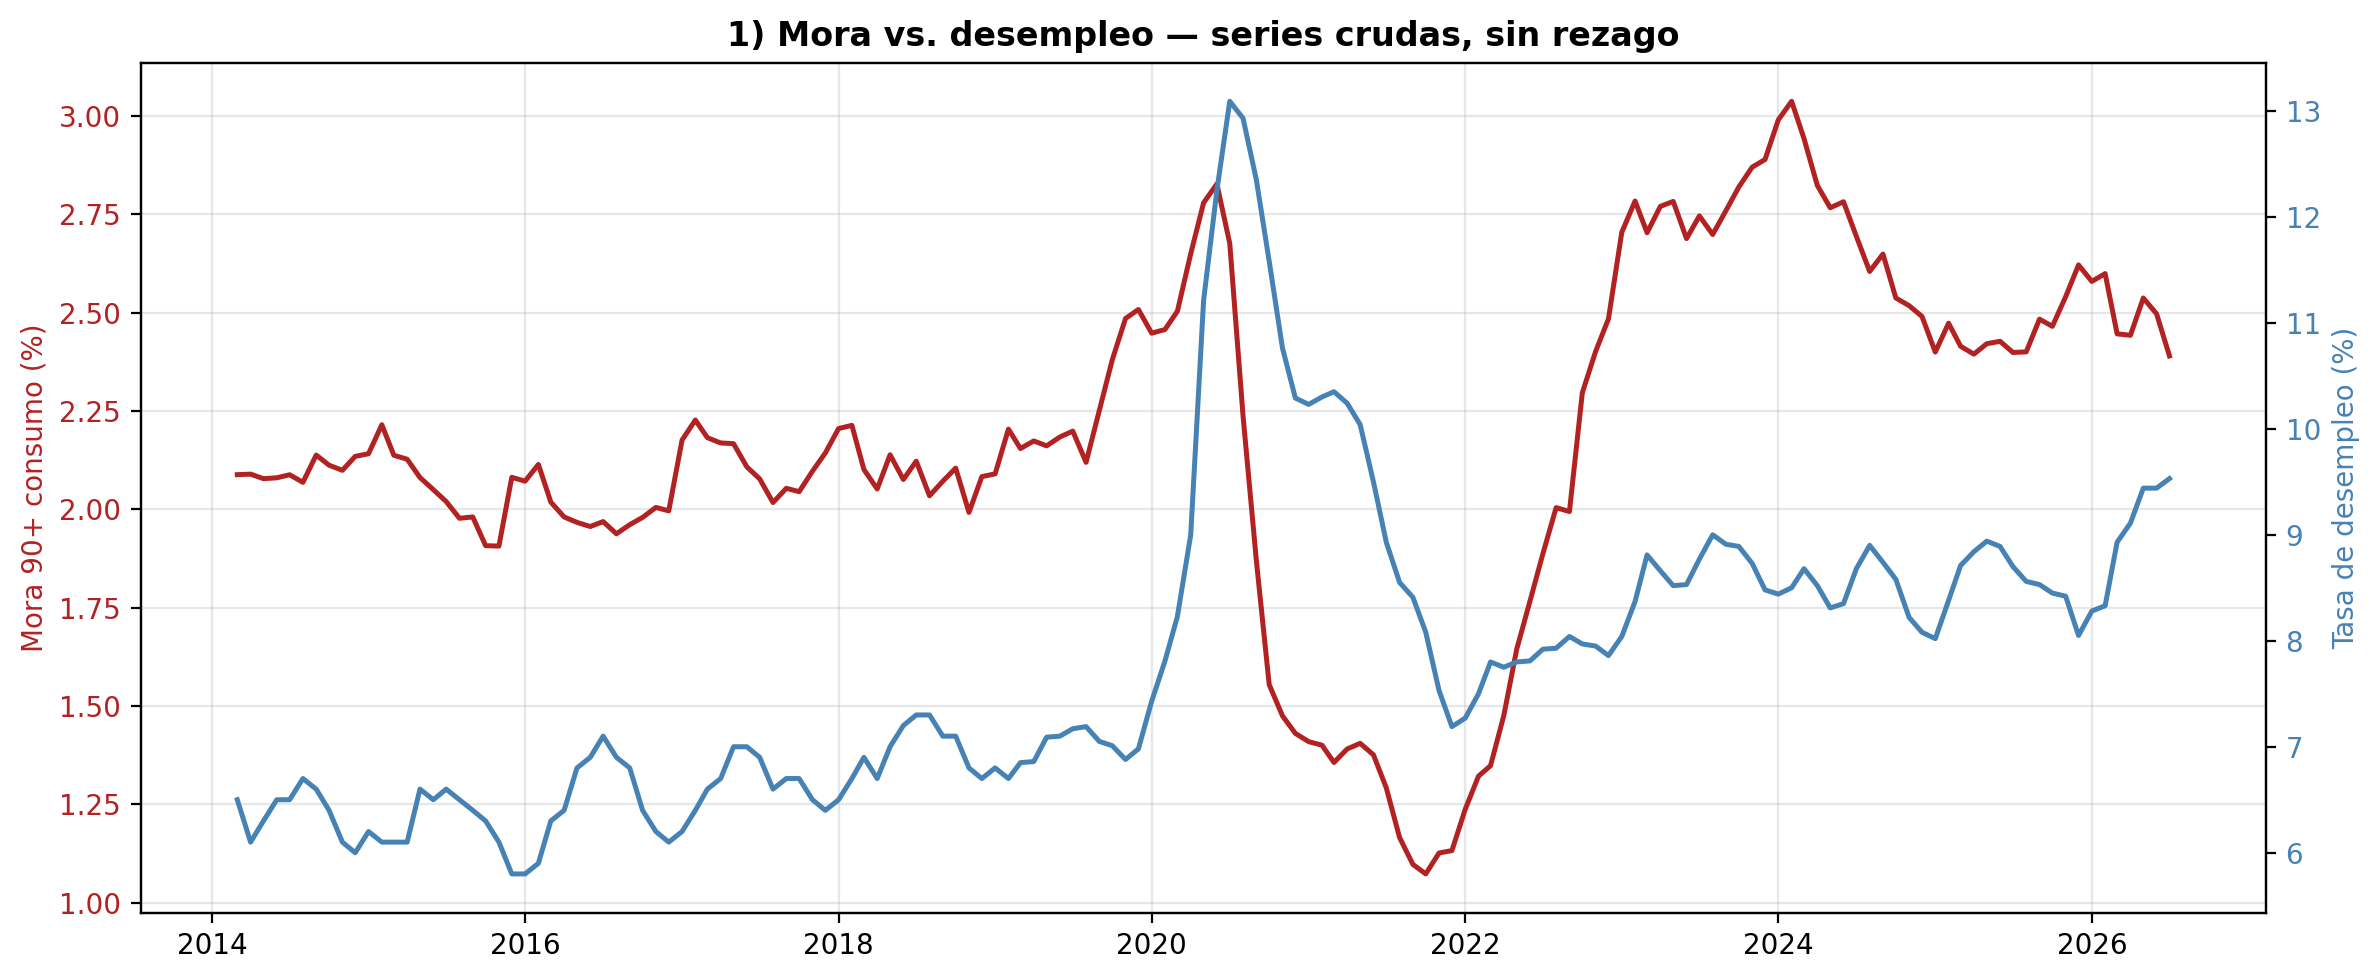

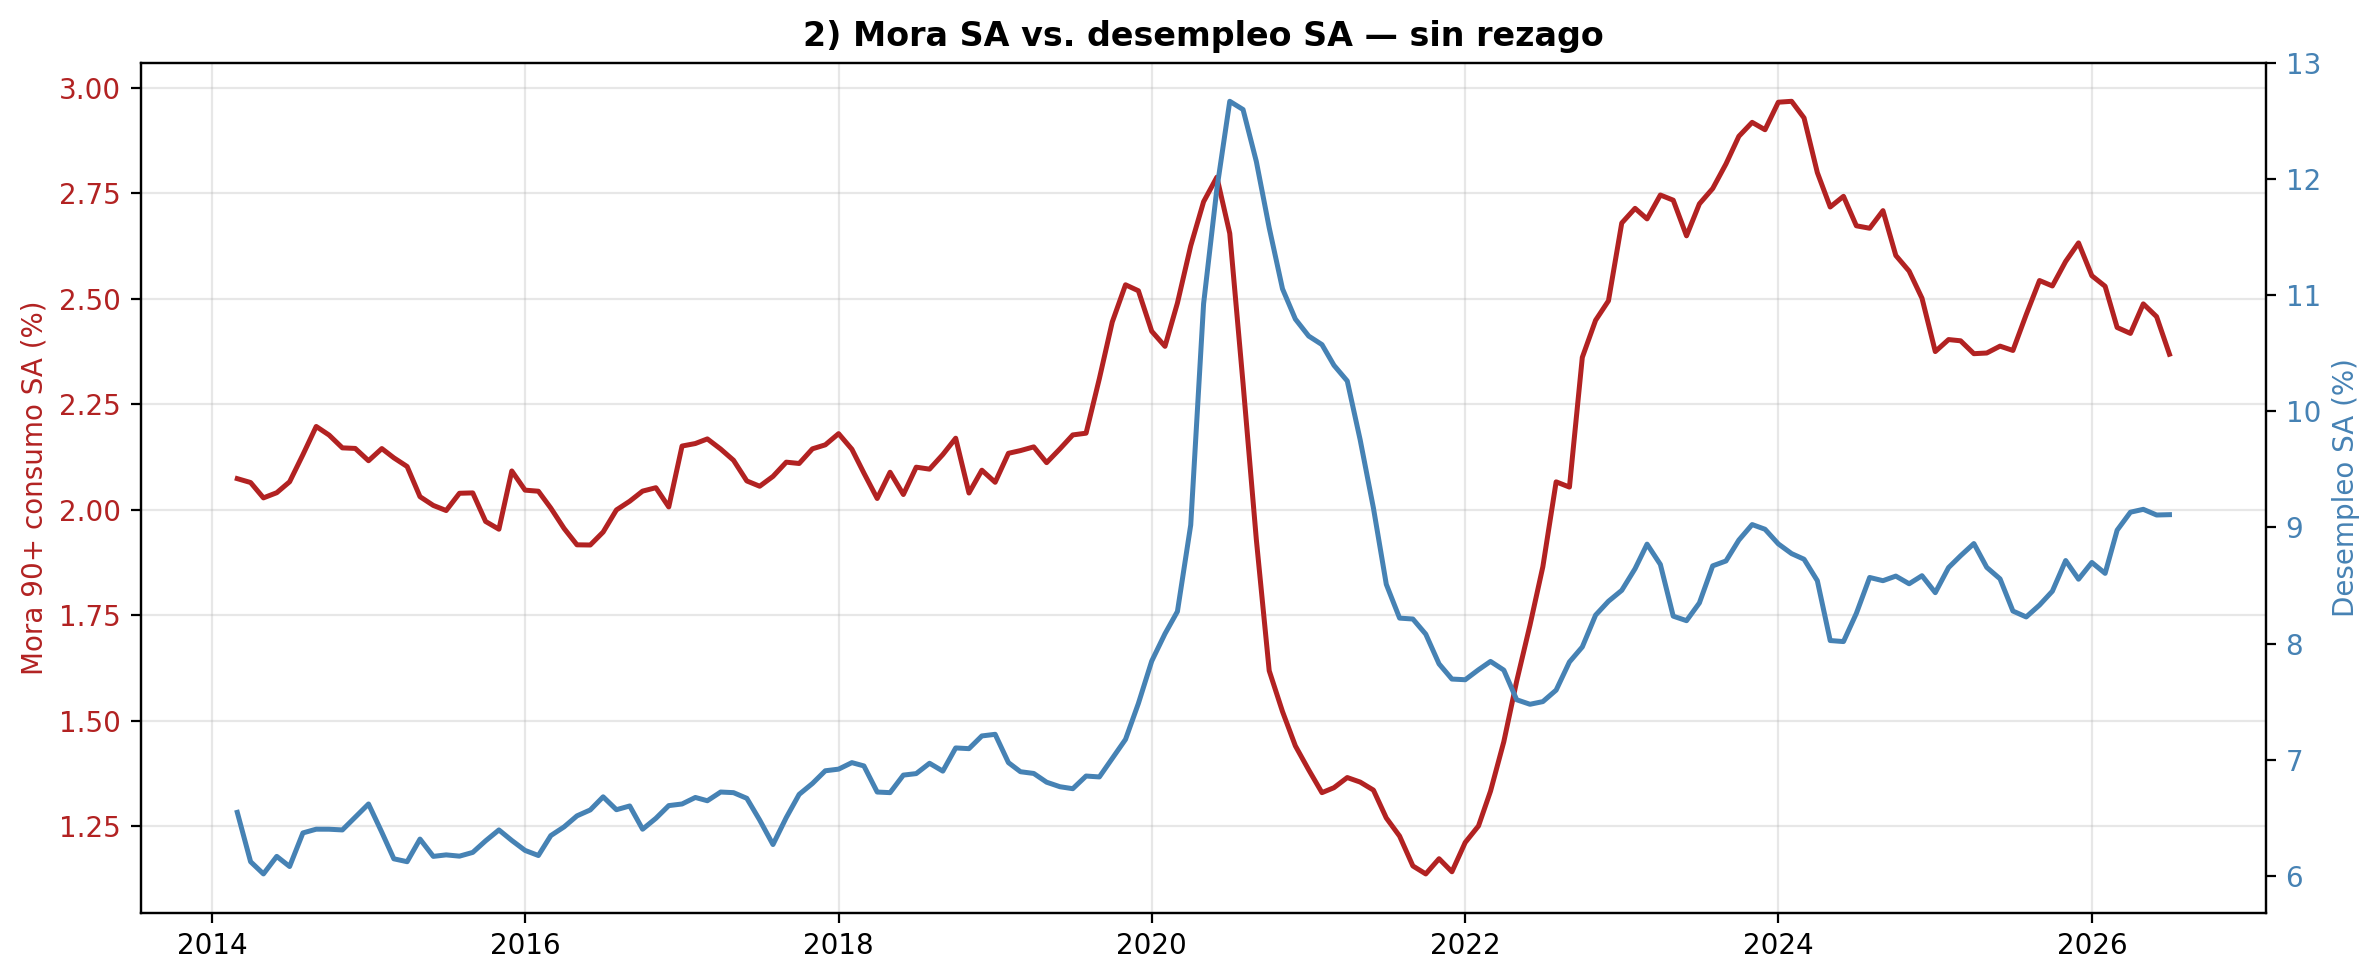

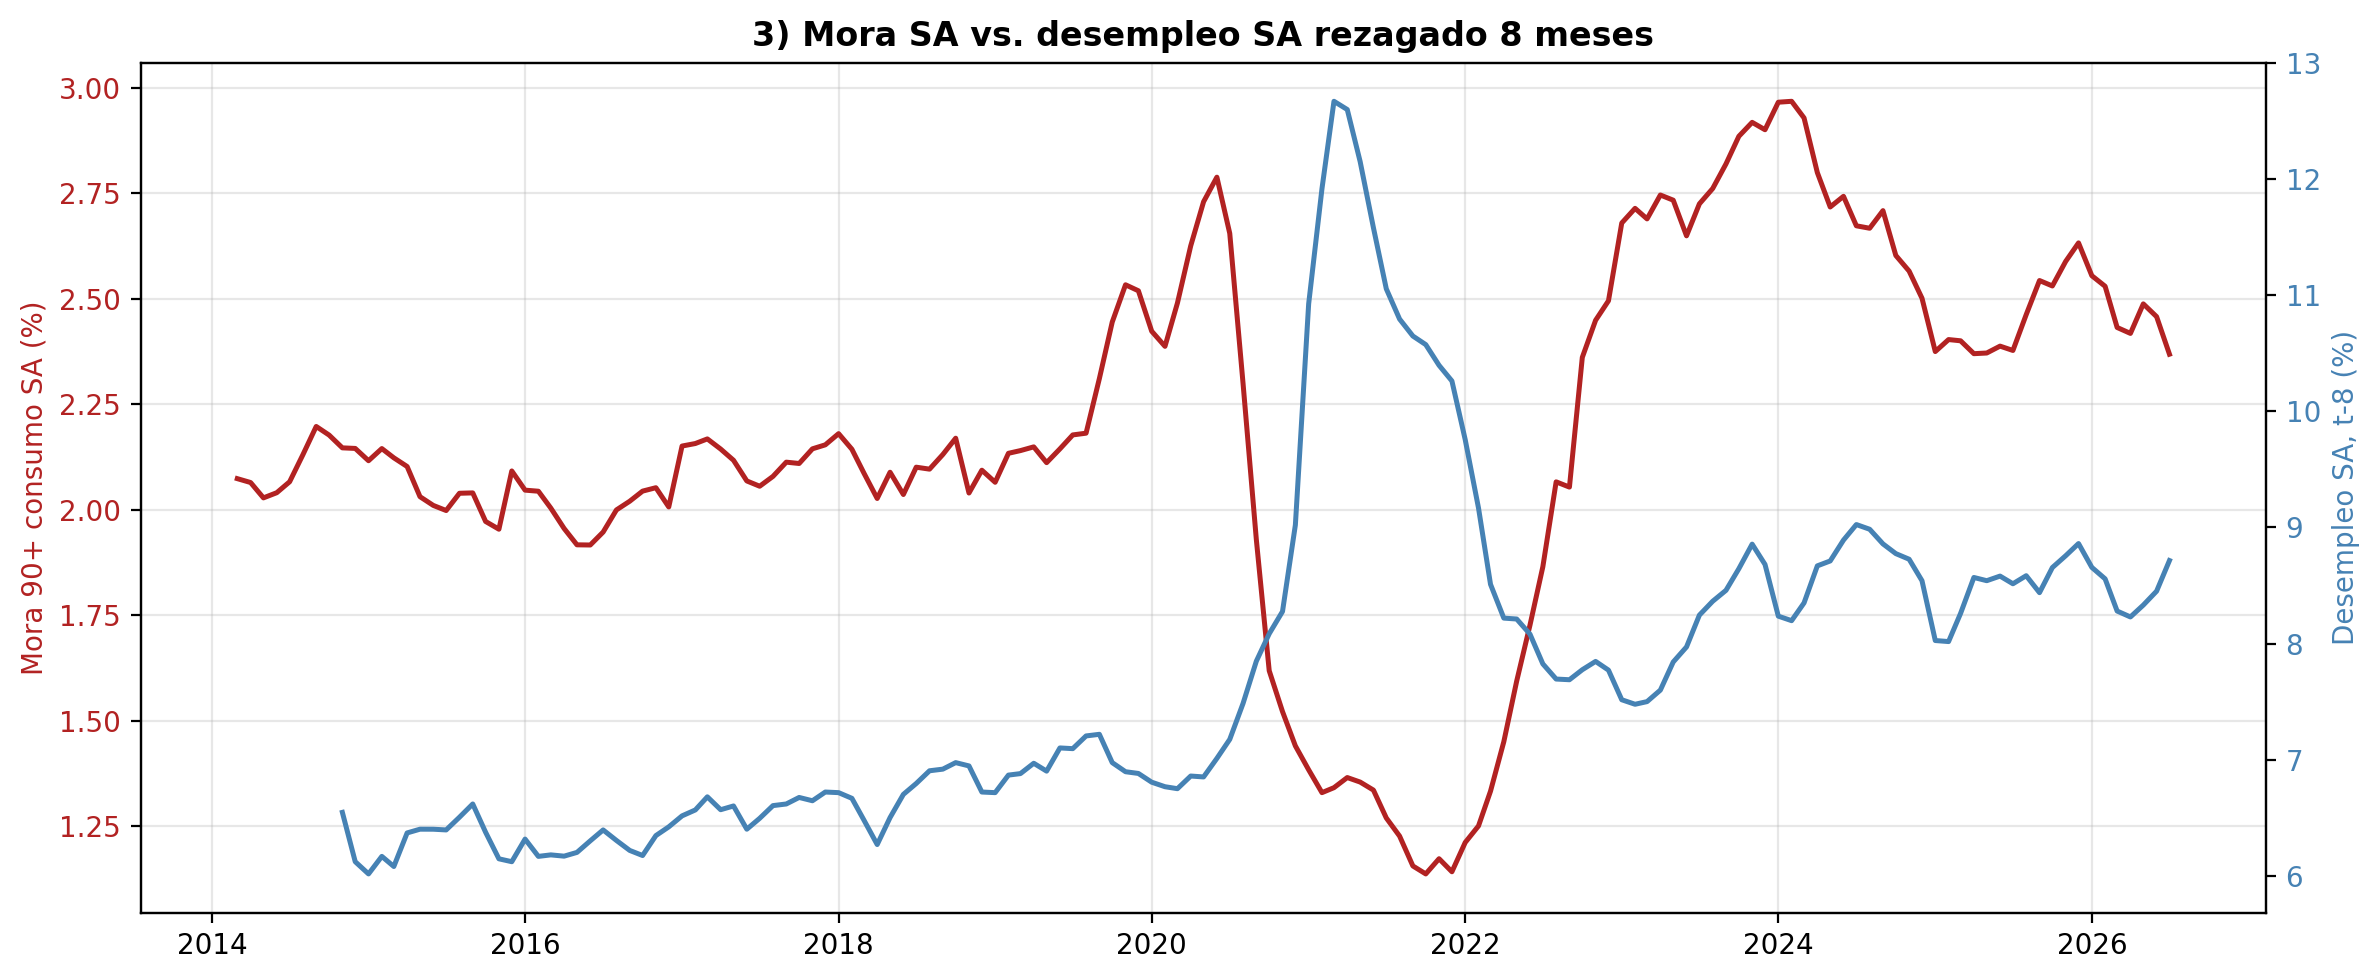

In [5]:
# ===== 1) Desempleo y mora, SIN desestacionalizar, sin rezago =====
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(Sx.index, Sx["Consumo"], color="firebrick", lw=1.8, label="Mora consumo (cruda)")
ax2.plot(Sx.index, Sx["desempleo"], color="steelblue", lw=1.8, label="Desempleo (crudo)")
ax1.set_ylabel("Mora 90+ consumo (%)", color="firebrick")
ax2.set_ylabel("Tasa de desempleo (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="firebrick"); ax2.tick_params(axis="y", labelcolor="steelblue")
ax1.set_title("1) Mora vs. desempleo — series crudas, sin rezago", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3); fig.tight_layout(); plt.show()

# ===== 2) Desempleo y mora, AMBAS desestacionalizadas, sin rezago =====
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(Sx.index, Sx["Consumo_sa"], color="firebrick", lw=1.8, label="Mora SA")
ax2.plot(Sx.index, Sx["desempleo_sa"], color="steelblue", lw=1.8, label="Desempleo SA")
ax1.set_ylabel("Mora 90+ consumo SA (%)", color="firebrick")
ax2.set_ylabel("Desempleo SA (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="firebrick"); ax2.tick_params(axis="y", labelcolor="steelblue")
ax1.set_title("2) Mora SA vs. desempleo SA — sin rezago", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3); fig.tight_layout(); plt.show()

# ===== 3) Desempleo SA rezagado 8 meses y mora SA — la relación que modela el ECM =====
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(Sx.index, Sx["Consumo_sa"], color="firebrick", lw=1.8, label="Mora SA")
ax2.plot(Sx.index, Sx["desempleo_sa"].shift(LAG), color="steelblue", lw=1.8, label=f"Desempleo SA (t-{LAG})")
ax1.set_ylabel("Mora 90+ consumo SA (%)", color="firebrick")
ax2.set_ylabel(f"Desempleo SA, t-{LAG} (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="firebrick"); ax2.tick_params(axis="y", labelcolor="steelblue")
ax1.set_title(f"3) Mora SA vs. desempleo SA rezagado {LAG} meses", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3); fig.tight_layout(); plt.show()

Tras observar las series, se aprecia que el desempleo sigue su tendencia al alza; al compararlo con la serie desestacionalizada se observa una leve baja, pero situándose muy cerca del 9%.

El desempleo se mantiene en niveles altos (sobre 9% SA desde marzo), que ya están incorporados en el pronóstico congelado. Según la IRF de la Parte 2, el efecto de estos niveles alcanza su máximo hacia el mes 11, por lo que su impacto pleno recae fuera de la ventana pronosticada (que llega a diciembre 2026). Esto marca un punto de monitoreo para checkpoints futuros más que una conclusión sobre los pronósticos actuales.


## 2 - Pronóstico vs. real: checkpoints out-of-time

En esta sección se contrasta el pronóstico contra los datos reales. Es importante entender que solo se cuenta con 3 observaciones, por lo que cualquier resultado debe tomarse con precaución.

Otro punto a considerar es que los siguientes gráficos contrastan el valor real del indicador contra el pronóstico estacionalizado. Si bien lo óptimo sería contrastar el pronóstico desestacionalizado con el valor desestacionalizado observado, esto último puede ser confuso para el público general.

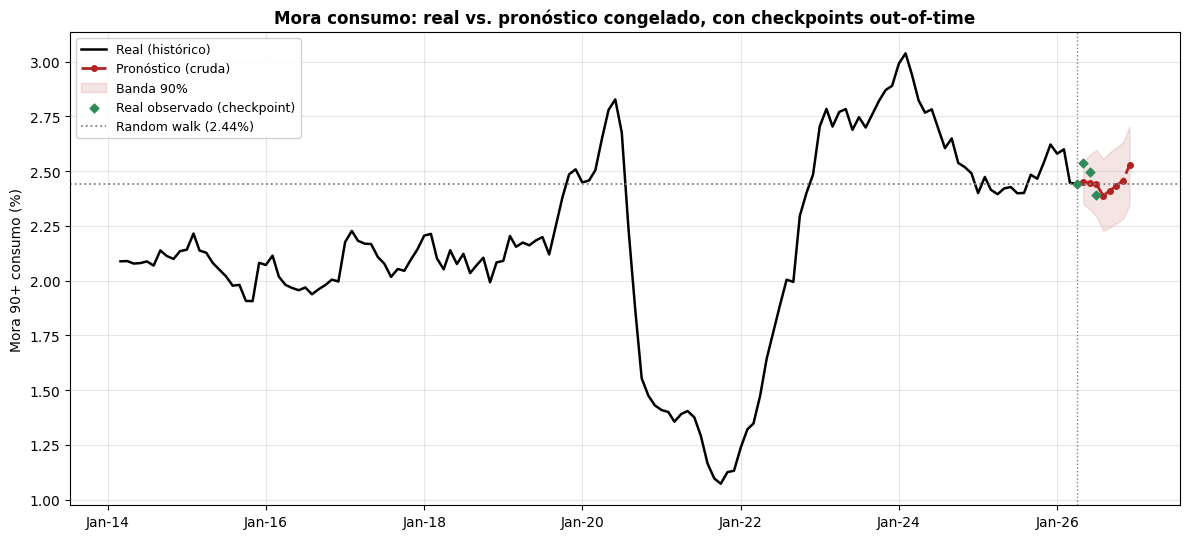

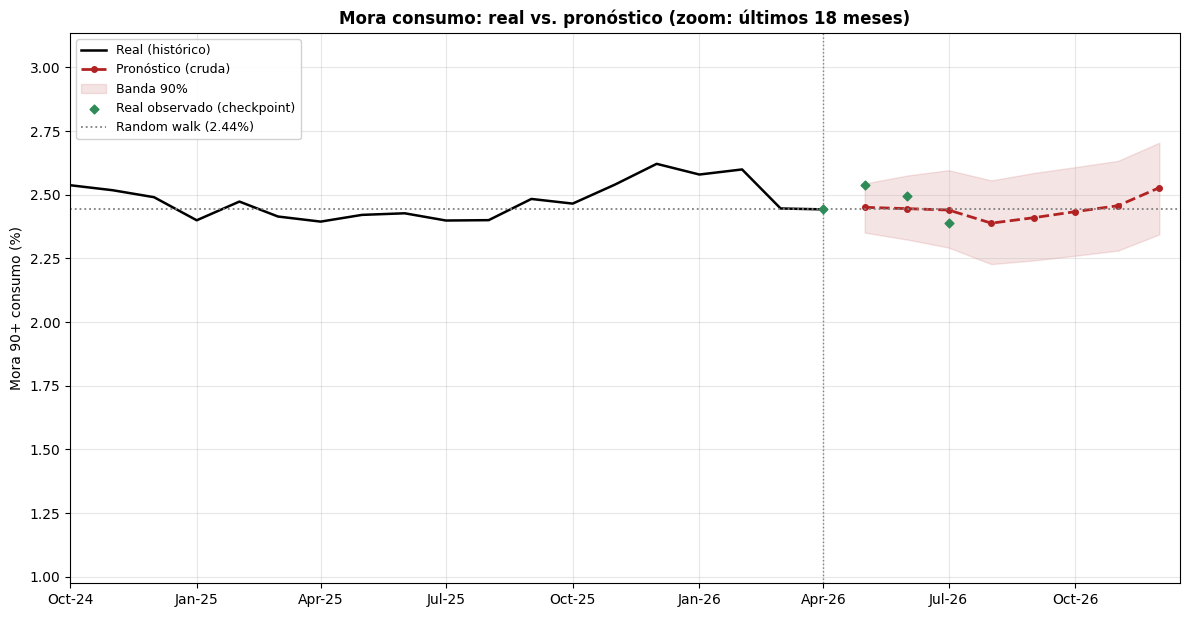

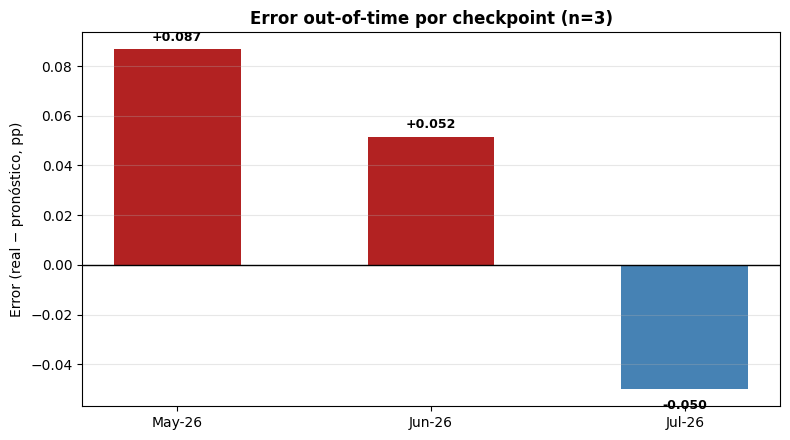

In [19]:
# ===== GRÁFICO 1: Real vs. pronóstico, con los checkpoints marcados =====
fig, ax = plt.subplots(figsize=(12, 5.5))

origen = pd.Timestamp("2026-04-01")  # último dato de entrenamiento (anclaje del RW también)

hist = control.loc[:origen, "Consumo"].dropna()
ax.plot(hist.index, hist.values, color="black", lw=1.8, label="Real (histórico)")

ax.plot(control.index, control["central"], color="firebrick", lw=2, ls="--",
        marker="o", ms=4, label="Pronóstico (cruda)")
ax.fill_between(control.index, control["p05"], control["p95"],
                 color="firebrick", alpha=0.12, label="Banda 90%")

checkpoints = control.loc[origen:, "Consumo"].dropna()
ax.scatter(checkpoints.index, checkpoints.values, color="seagreen", s=20, zorder=3,
           marker="D", label="Real observado (checkpoint)")

rw_valor = control.loc[origen, "Consumo"]
ax.axhline(rw_valor, color="grey", ls=":", lw=1.3, label=f"Random walk ({rw_valor:.2f}%)")

ax.axvline(origen, color="grey", ls=":", lw=1)
ax.set_ylabel("Mora 90+ consumo (%)")
ax.set_title("Mora consumo: real vs. pronóstico congelado, con checkpoints out-of-time",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout()
plt.show()


# ===== GRÁFICO 1.5: Zoom a los últimos 18 meses =====
fig, ax = plt.subplots(figsize=(12, 6.27))

hist = control.loc[:origen, "Consumo"].dropna()
ax.plot(hist.index, hist.values, color="black", lw=1.8, label="Real (histórico)")

ax.plot(control.index, control["central"], color="firebrick", lw=2, ls="--",
        marker="o", ms=4, label="Pronóstico (cruda)")
ax.fill_between(control.index, control["p05"], control["p95"],
                 color="firebrick", alpha=0.12, label="Banda 90%")

checkpoints = control.loc[origen:, "Consumo"].dropna()
ax.scatter(checkpoints.index, checkpoints.values, color="seagreen", s=20, zorder=3,
           marker="D", label="Real observado (checkpoint)")

rw_valor = control.loc[origen, "Consumo"]
ax.axhline(rw_valor, color="grey", ls=":", lw=1.3, label=f"Random walk ({rw_valor:.2f}%)")

ax.axvline(origen, color="grey", ls=":", lw=1)

ventana_inicio = origen - pd.DateOffset(months=18)
ax.set_xlim(ventana_inicio, control.index.max() + pd.Timedelta(days=15))

ax.set_ylabel("Mora 90+ consumo (%)")
ax.set_title("Mora consumo: real vs. pronóstico (zoom: últimos 18 meses)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout()
plt.show()

# ===== GRÁFICO 2: Error del checkpoint (real - pronóstico) =====
errores = control["error_cruda"].dropna()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["firebrick" if e > 0 else "steelblue" for e in errores]
bars = ax.bar(errores.index.strftime("%b-%y"), errores.values, color=colors, width=0.5)

for bar, val in zip(bars, errores.values):
    ax.annotate(f"{val:+.3f}", (bar.get_x() + bar.get_width()/2, val),
                textcoords="offset points", xytext=(0, 6 if val > 0 else -14),
                ha="center", fontsize=9, fontweight="bold")

ax.axhline(0, color="black", lw=1)
ax.set_ylabel("Error (real − pronóstico, pp)")
ax.set_title("Error out-of-time por checkpoint (n=3)", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


Se observa que los pronósticos de mayo y junio fueron subestimados, mientras que el de julio fue sobreestimado. Aún así, los tres valores observados siguen la tendencia a la baja pronosticada y se encuentran dentro de la banda de 90% preestablecida.

## 3 - Métricas de backtest y semáforo de tolerancia

En esta sección se realiza un análisis más formal, en donde se contrastan MAE, RMSE y Bias contra un random walk, y finalmente se construye un semáforo.

In [7]:
errores_ecm = control["error_cruda"].dropna()
n = len(errores_ecm)

mae_ecm, rmse_ecm, bias_ecm = errores_ecm.abs().mean(), np.sqrt((errores_ecm**2).mean()), errores_ecm.mean()

rw_valor   = control.loc[origen, "Consumo"]
errores_rw = control.loc[checkpoints.index, "Consumo"] - rw_valor
mae_rw, rmse_rw, bias_rw = errores_rw.abs().mean(), np.sqrt((errores_rw**2).mean()), errores_rw.mean()

mejora_rmse = 100 * (1 - rmse_ecm / rmse_rw)

en_banda  = control.loc[checkpoints.index, "Consumo"].between(
                control.loc[checkpoints.index, "p05"], control.loc[checkpoints.index, "p95"])
cobertura = en_banda.sum()

sub = control.loc[checkpoints.index, ["Consumo", "central"]].diff().dropna()
acierto_direccion = (np.sign(sub["Consumo"]) == np.sign(sub["central"])).sum()

resumen = pd.DataFrame({"MAE": [mae_ecm, mae_rw], "RMSE": [rmse_ecm, rmse_rw], "Bias": [bias_ecm, bias_rw]},
                        index=["ECM", "Random Walk"])
print(resumen.round(4).to_string())
print(f"\nMejora relativa RMSE (ECM vs RW): {mejora_rmse:.1f}%")
print(f"Cobertura banda 90%: {cobertura}/{n}")
print(f"Precisión direccional: {acierto_direccion}/{len(sub)} transiciones")


# ===== PANEL DE SEMÁFOROS (cada métrica contra su referencia correcta) =====
# RMSE base por horizonte, generado en la Parte 2 (ECM congelado, h=1..8)
rmse_base_h = pd.read_csv("rmse_base_ecm_por_horizonte.csv", index_col=0)["RMSE"]

# El horizonte máximo evaluado = cuántos checkpoints tengo (mayo=h1, junio=h2, ...)
# Uso la vara del horizonte más lejano que estoy midiendo, coherente con el RMSE agregado.
h_actual = min(n, int(rmse_base_h.index.max()))
RMSE_BASE = rmse_base_h.loc[h_actual]

def color_de(valor, verde, ambar):
    if valor <= verde:  return 2, "🟢 VERDE"
    if valor <= ambar:  return 1, "🟡 ÁMBAR"
    return 0, "🔴 ROJO"

semaforos = []

# 1) RMSE vs. desempeño histórico → degradación
r, e = color_de(rmse_ecm, 1.5*RMSE_BASE, 2.5*RMSE_BASE)
semaforos.append(("RMSE vs. base histórica", rmse_ecm,
                  f"≤{1.5*RMSE_BASE:.3f} / ≤{2.5*RMSE_BASE:.3f}", e, "degradación del modelo"))

# 2) RMSE vs. random walk → parsimonia (skill score)
skill = 1 - rmse_ecm/rmse_rw
if   skill >= 0.10: e2 = "🟢 VERDE"
elif skill >= 0.00: e2 = "🟡 ÁMBAR"
else:               e2 = "🔴 ROJO"
semaforos.append(("RMSE vs. random walk", skill,
                  "≥0.10 / ≥0.00", e2, "parsimonia (skill score)"))

# 3) Bias vs. cero → calibración direccional
r3, e3 = color_de(abs(bias_ecm), 1.0*RMSE_BASE, 1.5*RMSE_BASE)
semaforos.append(("|Bias| vs. cero", bias_ecm,
                  f"≤{1.0*RMSE_BASE:.3f} / ≤{1.5*RMSE_BASE:.3f}", e3, "sesgo direccional"))

print(f"\n{'Semáforo':26} {'Valor':>9}  {'Ref (V/A)':>16}  {'Estado':10} {'Detecta'}")
print("-"*90)
peor = 2
for nombre, val, ref, etiqueta, detecta in semaforos:
    rank = {"🟢 VERDE":2, "🟡 ÁMBAR":1, "🔴 ROJO":0}[etiqueta]
    peor = min(peor, rank)
    print(f"{nombre:26} {val:9.4f}  {ref:>16}  {etiqueta:10} {detecta}")

veredicto = {2:"🟢 VERDE", 1:"🟡 ÁMBAR", 0:"🔴 ROJO"}[peor]
print("-"*90)
print(f"VEREDICTO GENERAL (peor semáforo): {veredicto}")
print(f"Vara de referencia: RMSE base h={h_actual} = {RMSE_BASE:.4f}  (n={n} observaciones)")

UMBRAL_N_CONFIABLE = 6
if n < UMBRAL_N_CONFIABLE:
    print(f"⚠️  n={n} < {UMBRAL_N_CONFIABLE}: veredicto preliminar, no concluyente. "
          f"El bias es especialmente inestable con pocas observaciones.")


                MAE    RMSE    Bias
ECM          0.0628  0.0650  0.0294
Random Walk  0.0505  0.0607  0.0242

Mejora relativa RMSE (ECM vs RW): -7.2%
Cobertura banda 90%: 3/3
Precisión direccional: 2/2 transiciones

Semáforo                       Valor         Ref (V/A)  Estado     Detecta
------------------------------------------------------------------------------------------
RMSE vs. base histórica       0.0650   ≤0.131 / ≤0.218  🟢 VERDE    degradación del modelo
RMSE vs. random walk         -0.0723     ≥0.10 / ≥0.00  🔴 ROJO     parsimonia (skill score)
|Bias| vs. cero               0.0294   ≤0.087 / ≤0.131  🟢 VERDE    sesgo direccional
------------------------------------------------------------------------------------------
VEREDICTO GENERAL (peor semáforo): 🔴 ROJO
Vara de referencia: RMSE base h=3 = 0.0871  (n=3 observaciones)
⚠️  n=3 < 6: veredicto preliminar, no concluyente. El bias es especialmente inestable con pocas observaciones.


Tras observar el semáforo, y teniendo en cuenta que solo se cuenta con 3 observaciones, se puede concluir que el desempeño del modelo es aceptable. Esto se basa en:
* Los pronósticos se encuentran dentro de la banda de 90%.
* El RMSE del ECM contra su base histórica se mantiene por debajo del valor de referencia.
* El Bias se mantiene cercano a 0.


El único punto de alerta es el RMSE contra el Random Walk, pero al ser solo 3 observaciones no es un resultado concluyente.

Ahora que ya se descarta un mal desempeño del modelo, el paso siguiente es verificar si la relación se mantiene estable. Para ello, a continuación se ejecutará un CUSUM para evaluar la estabilidad de la relación de largo plazo y, posteriormente, una búsqueda de quiebres estructurales sobre el ECT.

## 4 - CUSUM: estabilidad de la relación de largo plazo

Antes de aplicar la función CUSUM, es conveniente graficar el ECT histórico. Esto nos permitirá entender por qué se omitió la ventana del período de pandemia y nos mostrará su evolución reciente.

In [8]:
# --- ECT bajo la especificación vigente (parámetros de la sección 0.3) ---
des_lag   = Sx["desempleo_sa"].shift(LAG)
phi_full  = (Sx.index >= BREAK).astype(float)
Sx["ECT"] = Sx["Consumo_sa"] - c0 - lam*phi_full - beta*des_lag

# --- CUSUM tabular (mismo k, h que en la Parte 2, celda del quiebre 2024) ---
ref = Sx["ECT"].loc["2024-04":"2026-04"]   # régimen post-quiebre, hasta el último mes de entrenamiento
mu, sd = ref.mean(), ref.std()

k, h = 0.5, 5.0
z = (Sx["ECT"].loc["2024-04":] - mu) / sd

Sp = Sm = 0.0
disparo = None
for t, zt in z.items():
    Sp = max(0, Sp + zt - k)
    Sm = max(0, Sm - zt - k)
    if max(Sp, Sm) > h and disparo is None:
        disparo = t
    if t >= pd.Timestamp("2026-01-01"):
        print(f"{t:%Y-%m}  S+={Sp:6.3f}  S-={Sm:6.3f}")

print(f"\n{'🚨 CUSUM dispara en ' + disparo.strftime('%Y-%m') if disparo else '✅ CUSUM no ha disparado a la fecha (último punto: ' + z.index[-1].strftime('%Y-%m') + ')'}")

if max(Sp, Sm) > 0.7 * h:
    print(f"⚠️  CUSUM al {100*max(Sp,Sm)/h:.0f}% del umbral — considera correr la "
          f"búsqueda de quiebres (ruptures + ITS) manualmente esta ronda.")


2026-01  S+= 0.000  S-= 1.966
2026-02  S+= 0.000  S-= 1.388
2026-03  S+= 0.000  S-= 0.754
2026-04  S+= 0.000  S-= 0.067
2026-05  S+= 0.045  S-= 0.000
2026-06  S+= 0.000  S-= 0.000
2026-07  S+= 0.000  S-= 1.868

✅ CUSUM no ha disparado a la fecha (último punto: 2026-07)


Se observa que el ECT, con excepción del período omitido durante su construcción, tampoco parece verse afectado por el quiebre estructural de abril 2024; esto último será evaluado en la sección 5 de este cuaderno.

Habiendo calculado y graficado el ECT, corresponde aplicar el CUSUM para evaluar si existe algún cambio en su comportamiento.

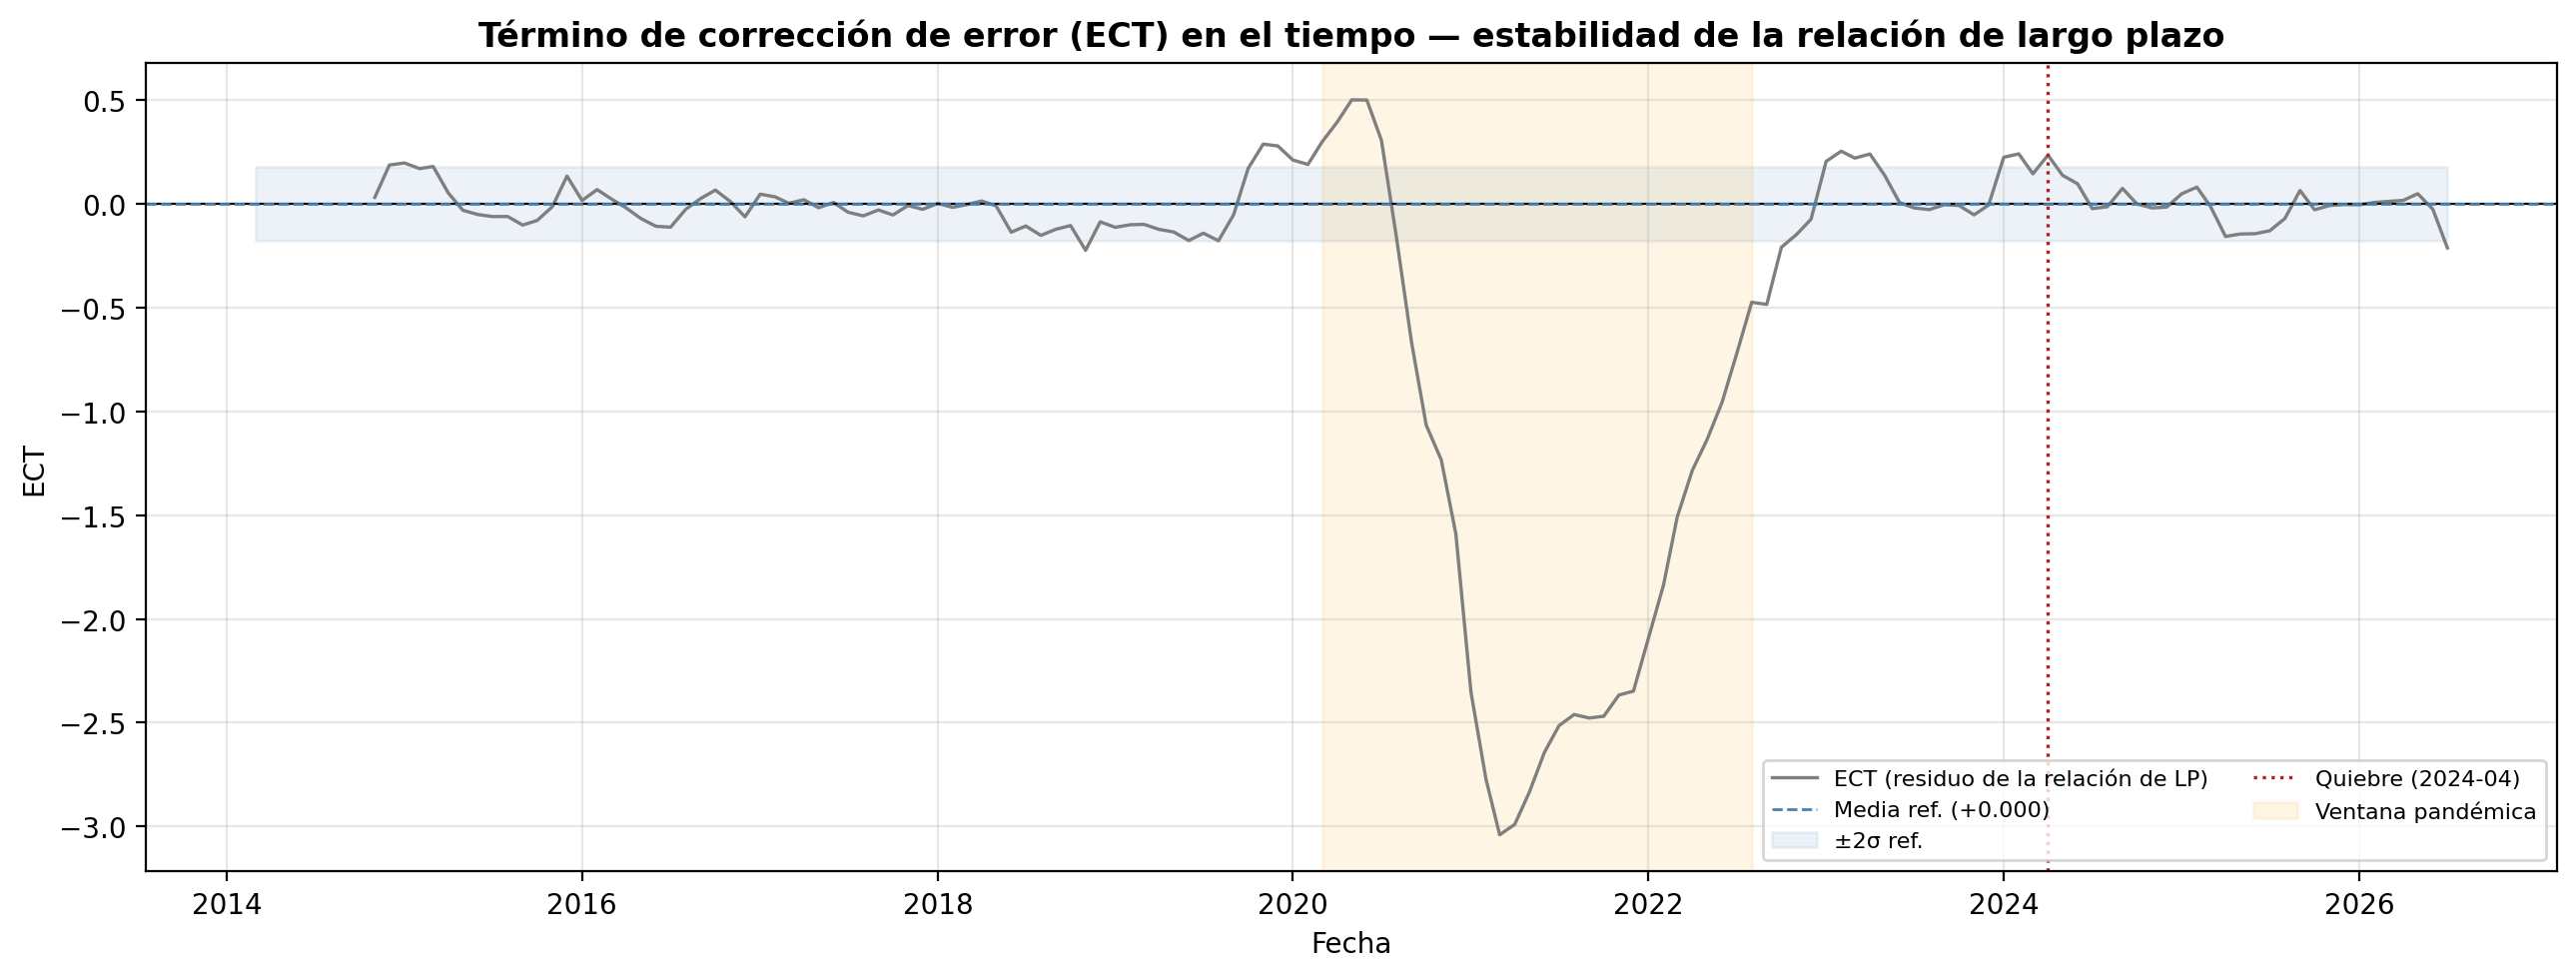

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(Sx.index, Sx["ECT"], color="#7f7f7f", lw=1.2, label="ECT (residuo de la relación de LP)")
ax.axhline(0, color="black", lw=0.8)

# media y bandas del régimen de referencia (post-quiebre, el mismo del CUSUM)
ref = Sx["ECT"].loc["2024-04":"2026-04"]
mu, sd = ref.mean(), ref.std()
ax.axhline(mu, color="steelblue", ls="--", lw=1, label=f"Media ref. ({mu:+.3f})")
ax.fill_between(Sx.index, mu-2*sd, mu+2*sd, color="steelblue", alpha=0.10, label="±2σ ref.")

# marcas de contexto: quiebre estructural y ventana pandémica
ax.axvline(BREAK, color="firebrick", ls=":", lw=1.2, label="Quiebre (2024-04)")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2022-08-01"),
           color="orange", alpha=0.10, label="Ventana pandémica")

ax.set_xlabel("Fecha"); ax.set_ylabel("ECT")
ax.set_title("Término de corrección de error (ECT) en el tiempo — estabilidad de la relación de largo plazo",
             fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Se observa que la función CUSUM no ha levantado ninguna alerta. El siguiente paso corresponde a buscar cambios estructurales en el ECT, pero dado que el CUSUM no se disparó, es esperable que no exista ningún cambio reciente.

## 5 - Búsqueda de quiebres sobre el ECT

Antes de buscar formalmente un cambio estructural, usaremos un scatter para verificar visualmente la relación de largo plazo, en donde durante el desarrollo del modelo se encontró la relación entre la mora consumo 90+(%) y el desempleo rezagado 8 meses. Cabe precisar que el scatter, al carecer de dimensión temporal, ilustra la consecuencia de un quiebre más que constituir evidencia formal de él; de ahí que la detección formal se haga a continuación sobre el ECT.

En este scatter es esperable que existan 4 grupos:
* Un grupo con un comportamiento "anómalo" dentro del período de pandemia, ya que durante el desarrollo del modelo este fue omitido.
* Un grupo pre-pandemia, en torno a la recta β = 0.370 sin quiebre.
* Un grupo post-pandemia y pre-quiebre, también en torno a la recta sin quiebre.
* Un grupo post-quiebre (desde abril de 2024), en torno a la recta con quiebre λ = -0.337.

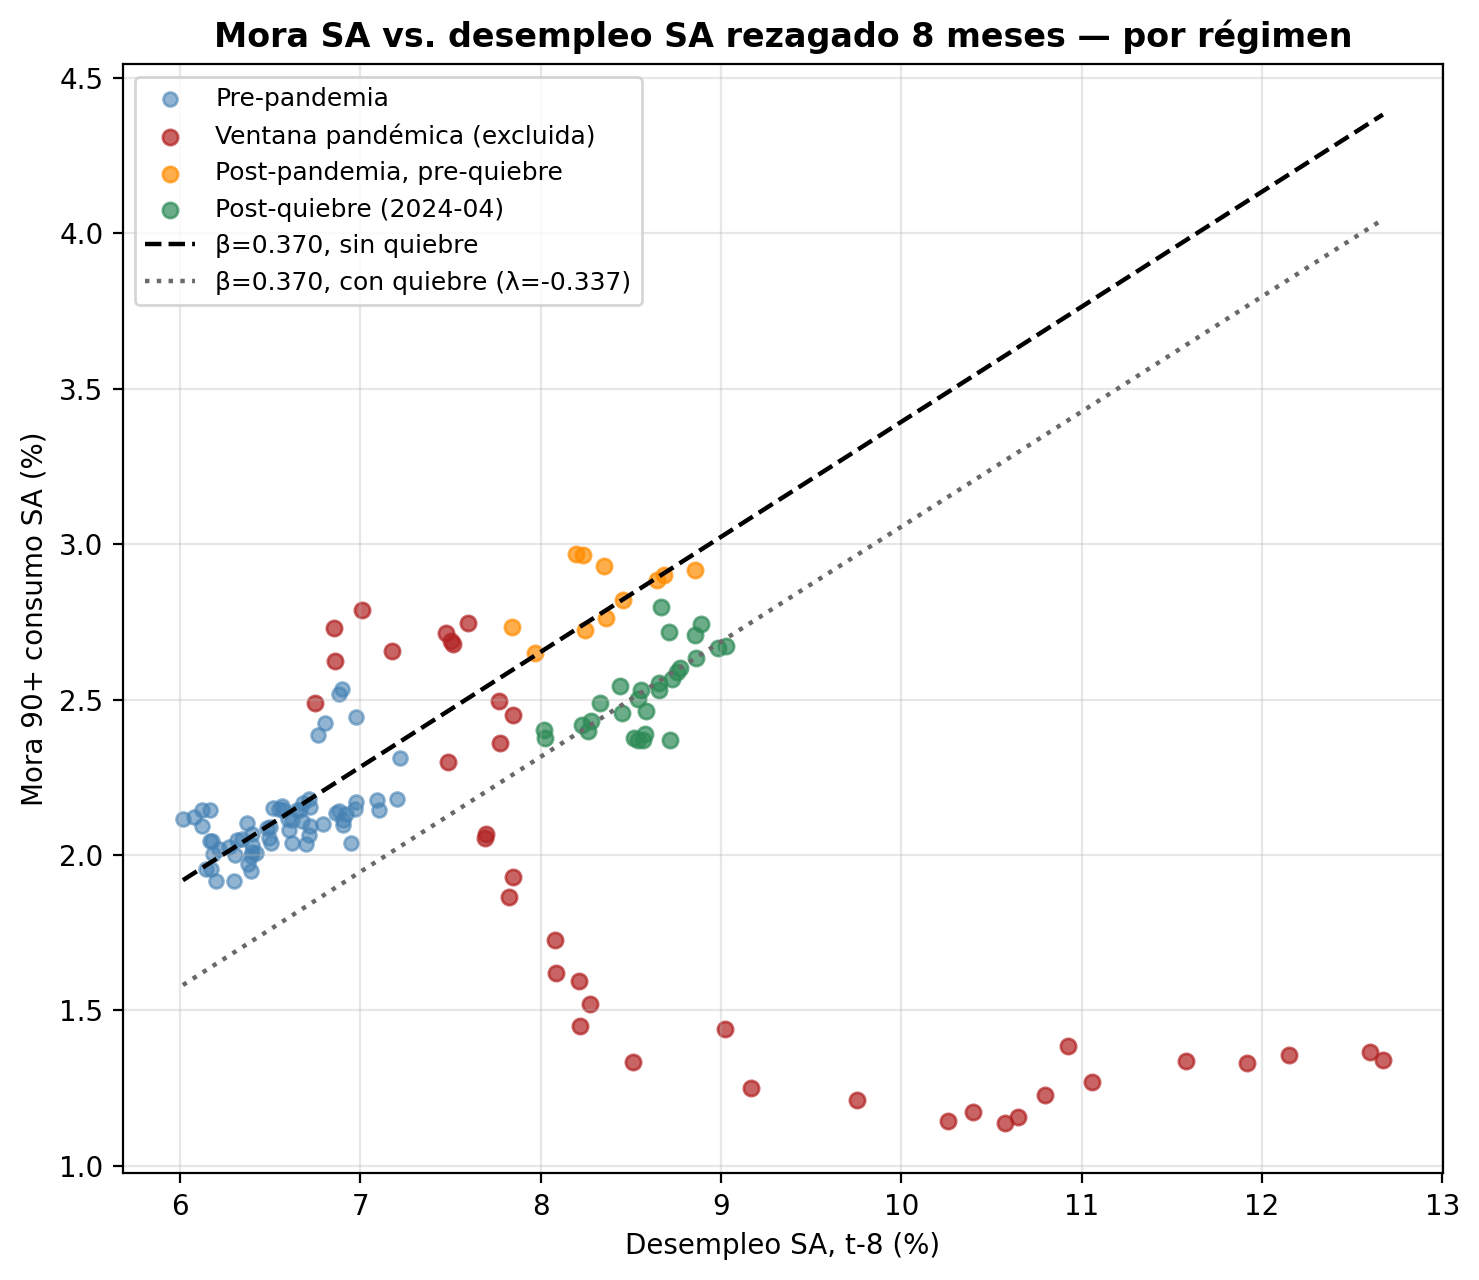

In [10]:
PAND_INI = pd.Timestamp("2020-03-01")
PAND_FIN = pd.Timestamp("2022-08-01")

f_lag_dates = Sx.index.to_series() - pd.DateOffset(months=LAG)
en_pand = (Sx.index.to_series().between(PAND_INI, PAND_FIN) |
           f_lag_dates.between(PAND_INI, PAND_FIN))

pre        = (~en_pand) & (Sx.index < PAND_INI)
entre      = (~en_pand) & (Sx.index > PAND_FIN) & (Sx.index < BREAK)   # fin pandemia → quiebre
post_break = (~en_pand) & (Sx.index >= BREAK)                          # desde el quiebre

x = Sx["desempleo_sa"].shift(LAG)
y = Sx["Consumo_sa"]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(x[pre],        y[pre],        color="steelblue", alpha=0.6, s=25, label="Pre-pandemia")
ax.scatter(x[en_pand],    y[en_pand],    color="firebrick", alpha=0.7, s=30, label="Ventana pandémica (excluida)")
ax.scatter(x[entre],      y[entre],      color="darkorange",alpha=0.7, s=30, label="Post-pandemia, pre-quiebre")
ax.scatter(x[post_break], y[post_break], color="seagreen",  alpha=0.7, s=30, label="Post-quiebre (2024-04)")

xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, c0 + beta*xs,       color="black",   lw=1.6, ls="--", label=f"β={beta:.3f}, sin quiebre")
ax.plot(xs, c0 + lam + beta*xs, color="dimgray", lw=1.6, ls=":",  label=f"β={beta:.3f}, con quiebre (λ={lam:.3f})")

ax.set_xlabel(f"Desempleo SA, t-{LAG} (%)")
ax.set_ylabel("Mora 90+ consumo SA (%)")
ax.set_title(f"Mora SA vs. desempleo SA rezagado {LAG} meses — por régimen", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Al revisar el scatter observamos que las observaciones se comportan como era esperado. Es importante recalcar que validar los supuestos del modelo mediante este ejercicio es recomendable en una validación inicial, pero repetirlo mensualmente no aporta mucho a la validación periódica.

A continuación realizaré la búsqueda de quiebres estructurales sobre el ECT, en donde es esperable que no aparezca uno nuevo dados los resultados del CUSUM.

En el siguiente bloque se buscarán cambios estructurales mediante la librería `ruptures`. Para no disparar el número de quiebres se usará el algoritmo Pelt, que decide de forma endógena cuántos quiebres justifican su costo según la penalización.

In [11]:


def detectar_quiebres_ect(ect, factor=2.0, model="l2", min_size=6):
    """Detecta quiebres en el ECT con Pelt (nº de quiebres endógeno).
    Penalización = factor * sigma^2 * log(n). Pelt decide cuántos quiebres
    justifican su costo; no se fija n_bkps de antemano."""
    y = ect.dropna().to_numpy()
    fechas = ect.dropna().index
    n = len(y)
    pen = factor * np.std(y)**2 * np.log(n)

    bkps = rpt.Pelt(model=model, min_size=min_size, jump=1).fit(y).predict(pen=pen)
    idx = bkps[:-1]   # el último punto es el fin de la serie, no un quiebre

    return {
        "n_quiebres": len(idx),
        "fechas": [fechas[i] for i in idx],
        "pen": pen,
    }

q = detectar_quiebres_ect(Sx["ECT"], factor=2.0)

if q["n_quiebres"] == 0:
    print("✅ Pelt no detectó quiebres en el ECT con esta penalización.")
else:
    print(f"⚠️  {q['n_quiebres']} quiebre(s) candidato(s):")
    for f in q["fechas"]:
        print(f"   {f:%Y-%m}")

⚠️  2 quiebre(s) candidato(s):
   2020-11
   2022-05


Se observan 2 candidatos a quiebre en el ECT. Ambos caen en la ventana pandémica omitida durante el desarrollo del modelo, por lo que no es necesario evaluar si son significativos. Este resultado —no encontrar cambios estructurales recientes— es consistente con el CUSUM de la función anterior, que no levantó ninguna alerta.

Si bien se determinó que los candidatos a quiebre cayeron durante la ventana de la pandemia, y por lo tanto no es necesario evaluar su significancia, en la próxima celda dejo un bloque que permite evaluar la significancia estadística de potenciales quiebres detectados. Esta herramienta queda **en reserva para una revisión gatillada**: se aplicaría solo si un checkpoint futuro dispara un quiebre genuinamente nuevo (posterior a abril de 2024). El bloque crea una regresión segmentada y opera de manera similar a una serie de tiempo interrumpida, con un regresor de nivel y otro de tendencia para cada candidato a quiebre. Los errores estándar se calculan mediante Newey-West (HAC) para evitar que estén sesgados por autocorrelación temporal.

In [12]:
def estimar_quiebres_hac(ect, quiebres, maxlags=None):
    """Regresión segmentada sobre el ECT con errores HAC (Newey-West).
    Nivel + pendiente base, y por cada quiebre un salto de nivel (dummy)
    y un cambio de pendiente (interacción tiempo*dummy).
    El ECT ya es un residuo desestacionalizado — entra directo, sin ajuste estacional.
    Estrellas: *** p<0.01, ** p<0.05, * p<0.1."""
    y_serie = ect.dropna()
    y = y_serie.to_numpy()
    n = len(y)
    t = np.arange(n)
    fechas_idx = y_serie.index

    idx_q = [fechas_idx.get_indexer([pd.to_datetime(q)], method="nearest")[0]
             for q in quiebres]

    X = np.column_stack([np.ones(n), t])
    nombres = ["const", "tiempo"]
    for i, k in enumerate(idx_q, start=1):
        D = (t >= k).astype(float)
        X = np.column_stack([X, D, D * t])
        nombres += [f"salto_nivel_q{i}", f"camb_pend_q{i}"]

    L = maxlags if maxlags is not None else int(np.floor(4 * (n / 100) ** (2 / 9)))
    modelo = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": L})

    def _estrellas(p):
        if p < 0.01:  return "***"
        elif p < 0.05: return "**"
        elif p < 0.10: return "*"
        return ""

    tabla = pd.DataFrame({
        "coef":    modelo.params,
        "ee_HAC":  modelo.bse,
        "t":       modelo.tvalues,
        "p_valor": modelo.pvalues,
        "sig":     [_estrellas(p) for p in modelo.pvalues],
    }, index=nombres)

    return {"modelo": modelo, "tabla": tabla, "fechas": quiebres,
            "idx": idx_q, "maxlags": L, "y": y, "fechas_idx": fechas_idx}

# uso:
# res_hac = estimar_quiebres_hac(Sx["ECT"], quiebres=["2020-11", "2022-05"])
# print(res_hac["tabla"].round(4).to_string())



## 6 - Pronóstico de referencia (8 meses, sin reestimar)

Se genera una trayectoria de referencia aplicando los parámetros ya congelados, sin reestimar el modelo. El horizonte se limita a 8 meses porque, con un rezago de 8 meses en el desempleo, ese es el alcance que se apoya en desempleo observado; más allá se asumiría desempleo constante, lo que introduciría un supuesto adicional. Esta trayectoria es solo referencial y no reemplaza el pronóstico congelado que se valida en el backtest.

In [13]:
def forecast_referencia(h=8):
    """
    Trayectoria de referencia: aplica los parámetros YA CONGELADOS (sección 0.3),
    sin reestimar, anclando el origen en el último dato real disponible hoy.
    NO reemplaza `forecast` (el congelado de abril 2026) en el backtest.
    """
    des, corte = Sx["desempleo_sa"], Sx.index[-1]
    hist   = list(Sx["Consumo_sa"].values[-3:])
    fechas = list(Sx.index[-3:])
    out = []
    for k in range(h):
        f_lag    = fechas[-1] - pd.DateOffset(months=LAG)
        des_val  = des.loc[f_lag] if (f_lag <= corte and f_lag in des.index) else des.iloc[-1]
        ect_prev = hist[-1] - c0 - lam*float(fechas[-1] >= BREAK) - beta*des_val
        nueva    = hist[-1] + (const + gamma*ect_prev + th1*(hist[-1]-hist[-2]) + th2*(hist[-2]-hist[-3]))
        out.append(nueva)
        hist.append(nueva); fechas.append(fechas[-1] + pd.DateOffset(months=1))
    fechas_f = pd.date_range(corte + pd.DateOffset(months=1), periods=h, freq="MS")
    return pd.Series(out, index=fechas_f, name="referencia_sa")

referencia = forecast_referencia(8)
print(referencia.round(3).to_string())




2026-08-01    2.388
2026-09-01    2.404
2026-10-01    2.439
2026-11-01    2.466
2026-12-01    2.512
2027-01-01    2.563
2027-02-01    2.609
2027-03-01    2.645
Freq: MS


## 7 - Log de checkpoints

Registro persistente: cada vez que se corre el notebook, se agrega (o actualiza, si el mes ya estaba) una fila por checkpoint disponible. Es la protección contra la revisión de datos de la CMF: sin esto, cada corrida futura recalcula todo desde cero y se pierde el rastro de qué se vio exactamente en cada fecha.

In [14]:
LOG_PATH = "log_checkpoints.csv"

nuevo = control.loc[checkpoints.index, ["Consumo", "central", "p05", "p95", "error_cruda"]].copy()
nuevo = nuevo.dropna(subset=["central"])   # quita el origen (abril), que no tiene pronóstico
nuevo["en_banda"]       = nuevo["Consumo"].between(nuevo["p05"], nuevo["p95"])
nuevo["fecha_registro"] = pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%d %H:%M:%S")
nuevo["rmse_acumulado"] = rmse_ecm
nuevo["semaforo"]       = veredicto
nuevo = nuevo.reset_index()
nuevo = nuevo.rename(columns={nuevo.columns[0]: "mes_checkpoint"})

try:
    log = pd.read_csv(LOG_PATH, parse_dates=["mes_checkpoint"])
except FileNotFoundError:
    log = pd.DataFrame(columns=nuevo.columns)

# upsert: si el mes ya estaba, se reemplaza con lo visto hoy
# (si la CMF revisa un dato histórico, la fila vieja se pierde — trade-off consciente)
log = log[~log["mes_checkpoint"].isin(nuevo["mes_checkpoint"])]
log = pd.concat([log, nuevo], ignore_index=True).sort_values("mes_checkpoint")

log.to_csv(LOG_PATH, index=False)
print(f"Log actualizado: {LOG_PATH}  ({len(log)} checkpoints registrados)")
print(log.tail(6).to_string(index=False))


Log actualizado: log_checkpoints.csv  (4 checkpoints registrados)
mes_checkpoint  Consumo  central      p05      p95  error_cruda  en_banda      fecha_registro  rmse_acumulado semaforo
    2026-04-01 2.442725      NaN      NaN      NaN          NaN     False 2026-09-12 20:23:11        0.065045   🔴 ROJO
    2026-05-01 2.537497 2.450752 2.351601 2.544116     0.086745      True 2026-09-13 02:41:06        0.065045   🔴 ROJO
    2026-06-01 2.497233 2.445636 2.324079 2.575762     0.051597      True 2026-09-13 02:41:06        0.065045   🔴 ROJO
    2026-07-01 2.390130 2.440185 2.292668 2.596644    -0.050055      True 2026-09-13 02:41:06        0.065045   🔴 ROJO


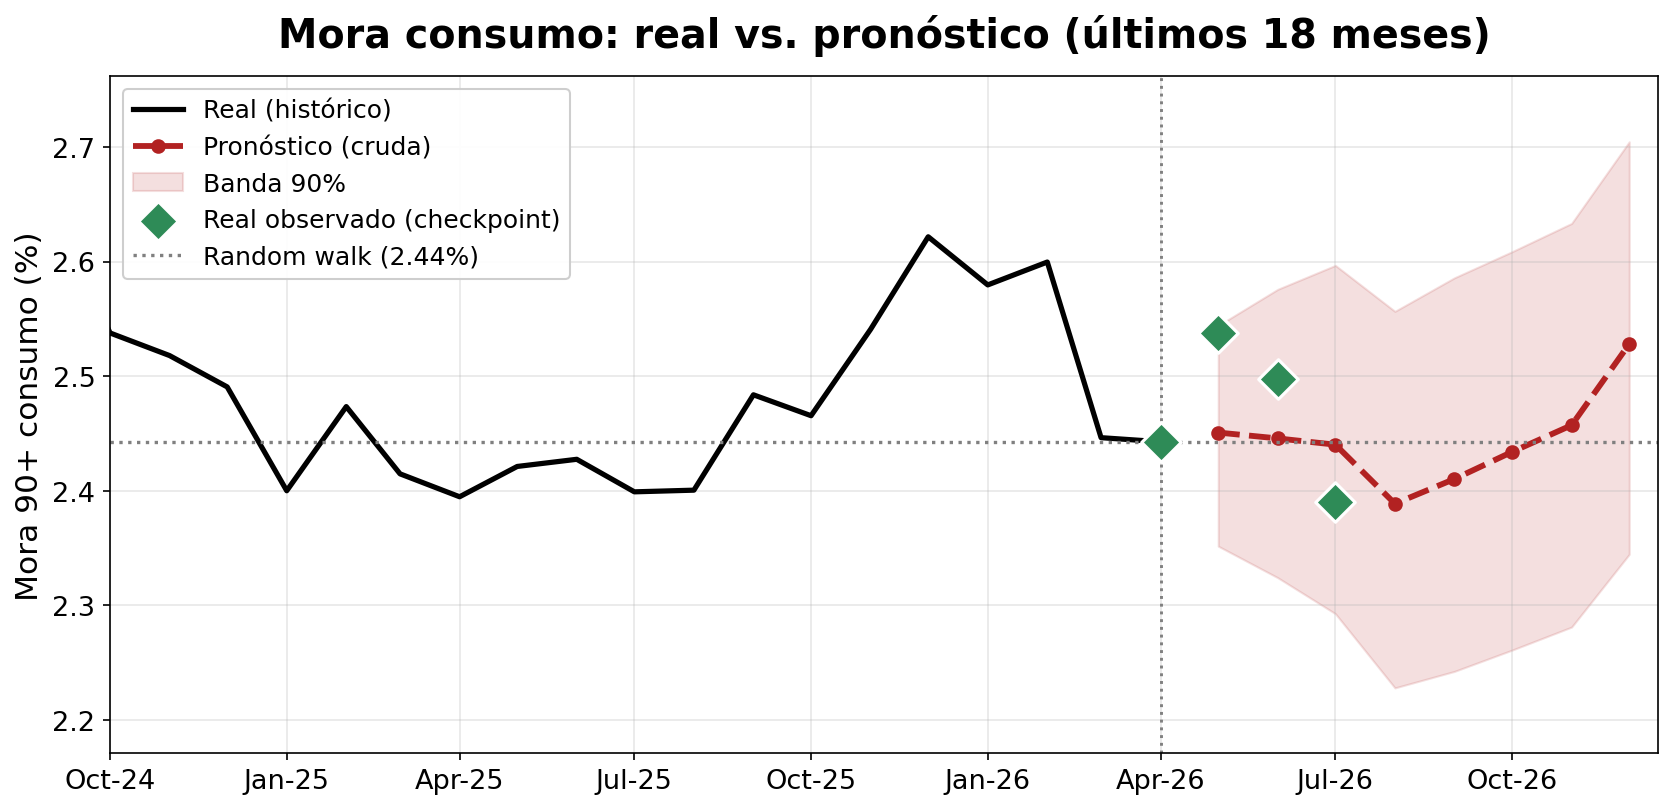

In [ ]:
# Este gráfico es solo para la portada de linkedin
fig = plt.figure(figsize=(12, 6.27), dpi=150, facecolor="white")   # dpi 150 → 1800x940 px

ax = fig.add_axes([0.09, 0.14, 0.86, 0.72])   # gráfico más grande dentro del lienzo

hist = control.loc[:origen, "Consumo"].dropna()
ax.plot(hist.index, hist.values, color="black", lw=2.5, label="Real (histórico)")

ax.plot(control.index, control["central"], color="firebrick", lw=2.8, ls="--",
        marker="o", ms=6, label="Pronóstico (cruda)")
ax.fill_between(control.index, control["p05"], control["p95"],
                color="firebrick", alpha=0.14, label="Banda 90%")

checkpoints = control.loc[origen:, "Consumo"].dropna()
ax.scatter(checkpoints.index, checkpoints.values, color="seagreen", s=180, zorder=5,
           marker="D", edgecolor="white", linewidth=1.5, label="Real observado (checkpoint)")

rw_valor = control.loc[origen, "Consumo"]
ax.axhline(rw_valor, color="grey", ls=":", lw=1.6, label=f"Random walk ({rw_valor:.2f}%)")
ax.axvline(origen, color="grey", ls=":", lw=1.4)

ventana_inicio = origen - pd.DateOffset(months=18)
ax.set_xlim(ventana_inicio, control.index.max() + pd.Timedelta(days=15))

visible = control.loc[ventana_inicio:, ["Consumo", "central", "p05", "p95"]]
y_min, y_max = visible.min().min(), visible.max().max()
margen = (y_max - y_min) * 0.12
ax.set_ylim(y_min - margen, y_max + margen)

ax.set_ylabel("Mora 90+ consumo (%)", fontsize=15)
ax.set_title("Mora consumo: real vs. pronóstico (últimos 18 meses)",
             fontsize=19, fontweight="bold", pad=14)
ax.legend(loc="upper left", fontsize=12, framealpha=0.95)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
ax.tick_params(labelsize=13)

plt.savefig("portada_parte3.png", dpi=150, facecolor="white")
plt.show()